# Segmentation Comportementale des Agents & Prédiction du Segment d'Appartenance
### Programme d'Estivage OCP — Site de Khouribga — Campagne 2026


## Sommaire

1. Contexte et objectifs
2. Import des librairies
3. Chargement des données
4. Préparation des données au niveau agent
5. Sélection et justification des variables de segmentation
6. Prétraitement des données
7. Détermination du nombre optimal de clusters
8. Application du clustering final
9. Profilage des segments
10. Interprétation métier des segments
11. Visualisation comparative
12. Volet prédictif — objectif et préparation des données
13. Entraînement et comparaison des modèles
14. Évaluation détaillée du modèle retenu
15. Importance des variables
16. Fonction opérationnelle de prédiction
17. Export des résultats pour SQL Server / Power BI
18. Conclusion et recommandations métier

---

## 1. Contexte et objectifs

Le service social de l'OCP dispose d'un programme d'estivage permettant aux agents de bénéficier de séjours (chalets, résidences conventionnées, hôtels-club) avec une prise en charge partielle de l'employeur. Cette phase vise à :

1. **Segmenter les agents** en groupes homogènes selon leur comportement de consommation, leur fidélité au programme et leur profil financier.
2. **Prédire automatiquement** le segment d'un agent à partir de son profil, afin de permettre au service social de personnaliser ses offres et sa communication.

**Problématique :** Comment exploiter le comportement de consommation, la fréquence d'utilisation et le profil financier des agents pour construire une segmentation fine et actionnable, puis prédire automatiquement le segment d'un agent afin d'appuyer les décisions du service social (personnalisation de l'offre, ciblage, anticipation de la demande) ?

**Unité d'analyse :** l'agent (matricule), et non la demande — un agent peut avoir soumis 1 ou 2 demandes sur la campagne.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gower

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, silhouette_score
from sklearn.inspection import permutation_importance

from kmodes.kprototypes import KPrototypes

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

RANDOM_STATE = 42

## 3. Chargement des données

In [2]:
CSV_PATH = "dataset_ocp_social_2026_nettoye_enrichi_final_version2.csv"

df = pd.read_csv(CSV_PATH, encoding="utf-8-sig")

print("Dimensions du fichier :", df.shape)
print("Nombre d'agents uniques :", df['matricule'].nunique())
print("Nombre de demandes :", len(df))
df.head(3)

Dimensions du fichier : (5000, 55)
Nombre d'agents uniques : 4350
Nombre de demandes : 5000


,numero_demande,site,matricule,nom_agent,prenom_agent,genre,situation_familiale,categorie_professionnelle,anciennete_annees,annees_depuis_dernier_sejour,nombre_points,type_produit,nom_etablissement,ville,id_periode,saison,date_demande,date_debut_sejour,date_fin_sejour,nombre_nuitees,periode_classement_debut,periode_classement_fin,date_limite_demande,date_limite_paiement,nombre_enfants,nombre_accompagnants,nombre_enfants_chambre_parents,total_membres_famille,nombre_chambres_double,nombre_chambres_simple,type_vue_config,formule_restauration,montant_total_sejour,quote_part_agent,montant_pris_charge_ocp,rang_classement,date_traitement,statut_apres_classement,reference_paiement,statut_paiement,date_paiement,statut_demande,numero_voucher,date_tirage_voucher,nombre_pieces,capacite_logement,type_vue,delai_traitement_jours,delai_paiement_jours,anticipation_reservation_jours,taux_prise_charge_ocp,taux_participation_agent,cout_par_personne,categorie_taille_groupe,categorie_anciennete
0,CH104001,Khouribga,5028,Sefrioui,Noureddine,Homme,Célibataire,"Ingénieurs, cadres et assimilés",2,5,225,Résidence conventionnée,Résidence Al Firdaous Saidia,Saidia,P3,Basse,2026-01-14,2026-02-21,2026-03-03,10,2026-02-07,2026-02-14,2026-02-06,2026-02-18,0,2,0,3,0,2,2 chambre(s) + salon (3 pers) - Vue standard,All Inclusive,12411.62,3574.22,8837.40,4,2026-02-08,Acceptée,71260.0,Payé,2026-02-09,Confirmée,VOU-2026-02137,2026-02-12,3,3,Vue standard,25,1.0,38,71.20,28.80,4137.21,Petite famille,Débutant
1,CH103163,Khouribga,3746,El Ghazouani,Malika,Femme,Mariée,"Ingénieurs, cadres et assimilés",12,5,271,Chalet OCP,Chalet OCP Cabo Negro,Cabo Negro,P3,Haute,2026-05-31,2026-07-15,2026-07-25,10,2026-06-16,2026-06-23,2026-06-15,2026-06-23,0,1,0,2,1,0,1 chambre(s) + salon (2 pers) - Vue jardin,Demi-pension,4371.06,1315.18,3055.88,3,2026-06-23,Acceptée,61783.0,Payé,2026-06-23,Confirmée,VOU-2026-00452,2026-06-25,2,2,Vue jardin,23,0.0,45,69.91,30.09,2185.53,Couple,Intermédiaire
2,CH103315,Khouribga,6882,Sabri,Aicha,Femme,Célibataire,"Ingénieurs, cadres et assimilés",1,3,146,Résidence conventionnée,Résidence Al Manar M'diq,M'diq,P6,Haute,2026-06-16,2026-07-31,2026-08-08,8,2026-06-29,2026-07-03,2026-06-26,2026-07-06,0,0,0,1,0,1,1 chambre(s) + salon (1 pers) - Vue mer,Demi-pension,2788.32,517.30,2271.02,4,2026-07-03,Acceptée,55790.0,Payé,2026-07-04,Confirmée,VOU-2026-02284,2026-07-07,2,1,Vue mer,17,1.0,45,81.45,18.55,2788.32,Individuel,Débutant


## 4. Préparation des données au niveau agent

Le fichier est au grain "demande" (une ligne par demande soumise). Pour construire un profil d'agent, on agrège les données par `matricule` :
- les attributs propres à l'agent (genre, situation familiale, catégorie professionnelle, ancienneté, points...) sont pris une seule fois (`first`), car ils sont identiques sur toutes les demandes d'un même agent ;
- les attributs liés au comportement de consommation (produit choisi, ville, durée de séjour, montants...) sont résumés par leur **moyenne** (valeurs numériques) ou leur **valeur la plus fréquente** (catégories), afin de représenter le comportement global de l'agent sur la campagne.

In [3]:
def mode_or_first(s):
    m = s.mode()
    return m.iloc[0] if not m.empty else s.iloc[0]

agg_rules = {
    'genre': 'first',
    'situation_familiale': 'first',
    'categorie_professionnelle': 'first',
    'anciennete_annees': 'first',
    'categorie_anciennete': 'first',
    'nombre_points': 'first',
    'annees_depuis_dernier_sejour': 'first',
    'nombre_enfants': 'mean',
    'total_membres_famille': 'mean',
    'categorie_taille_groupe': mode_or_first,
    'type_produit': mode_or_first,
    'ville': mode_or_first,
    'formule_restauration': mode_or_first,
    'saison': mode_or_first,
    'type_vue': mode_or_first,
    'montant_total_sejour': 'mean',
    'quote_part_agent': 'mean',
    'taux_prise_charge_ocp': 'mean',
    'cout_par_personne': 'mean',
    'anticipation_reservation_jours': 'mean',
    'nombre_nuitees': 'mean',
    'numero_demande': 'count',
    'statut_apres_classement': lambda s: (s == 'Acceptée').mean(),
}

agent_df = df.groupby('matricule').agg(agg_rules).reset_index()
agent_df = agent_df.rename(columns={'numero_demande': 'nombre_demandes', 'statut_apres_classement': 'taux_acceptation'})

print("Table au niveau agent :", agent_df.shape)
agent_df.head()

Table au niveau agent : (4350, 24)


,matricule,genre,situation_familiale,categorie_professionnelle,anciennete_annees,categorie_anciennete,nombre_points,annees_depuis_dernier_sejour,nombre_enfants,total_membres_famille,categorie_taille_groupe,type_produit,ville,formule_restauration,saison,type_vue,montant_total_sejour,quote_part_agent,taux_prise_charge_ocp,cout_par_personne,anticipation_reservation_jours,nombre_nuitees,nombre_demandes,taux_acceptation
0,1001,Femme,Mariée,Employés,1,Débutant,104,2,3.0,7.0,Grande famille,Résidence conventionnée,Agadir,All Inclusive,Haute,Vue mer,17640.51,3248.72,81.58,2520.07,44.0,6.0,1,0.0
1,1002,Femme,Mariée,Employés,1,Débutant,111,2,2.0,6.0,Grande famille,Résidence conventionnée,Ifrane,Demi-pension,Basse,Vue jardin,18148.14,4186.50,76.93,3024.69,38.0,8.0,1,1.0
2,1003,Homme,Marié,Employés,4,Débutant,128,2,1.0,4.0,Petite famille,Résidence conventionnée,Saidia,All Inclusive,Basse,Vue mer,14466.20,4764.78,67.06,3616.55,22.0,10.0,1,1.0
3,1006,Homme,Célibataire,Employés,9,Intermédiaire,113,1,0.0,3.0,Petite famille,Résidence conventionnée,El Jadida,Demi-pension,Haute,Vue mer,5635.86,1027.34,81.77,1878.62,46.0,6.0,1,0.0
4,1011,Femme,Célibataire,Ouvriers et opérateurs,19,Expérimenté,208,2,0.0,1.0,Individuel,Hôtel-Club,Tanger,All Inclusive,Haute,Vue mer,3118.03,673.89,78.39,3118.03,45.0,6.0,1,1.0


## 5. Sélection et justification des variables de segmentation

L'objectif est de regrouper les agents selon leur **comportement de consommation, leur fidélité au programme et leur profil financier**. La sélection des variables suit une règle stricte : n'inclure que des informations qui décrivent comment l'agent utilise le programme, en excluant tout ce qui n'apporte pas de signal utile ou qui introduit du bruit.

**Variables exclues et justification :**

| Catégorie | Colonnes | Raison de l'exclusion |
|---|---|---|
| Identifiants | matricule, nom_agent, prenom_agent, numero_demande, reference_paiement, numero_voucher | Aucune signification pour une distance de clustering |
| Composition et hébergement familial | nombre_enfants, nombre_accompagnants, total_membres_famille, nombre_chambres_double/simple, nombre_pieces, capacite_logement, categorie_taille_groupe, montant_total_sejour | Ces variables décrivent uniquement la taille du foyer et sa traduction en besoin d'hébergement ; elles n'apportent pas d'information sur le comportement ou la fidélité de l'agent |
| Résultats administratifs | rang_classement, statut_apres_classement, statut_paiement, dates de traitement/paiement, délais | Ce sont des résultats du processus de traitement, pas des caractéristiques de l'agent |
| Sans pouvoir discriminant | site (valeur unique "Khouribga"), type_vue_config (redondant avec la capacité du logement), nom_etablissement (trop fin, déjà résumé par la ville) | Aucune variance exploitable ou doublon d'une autre variable |
| `taux_participation_agent` | — | Colinéaire à 100% avec `taux_prise_charge_ocp` (leur somme vaut toujours 100), ferait doublon |

**Variables retenues, validées empiriquement (corrélation avec la taille du foyer < 0,12, donc un signal propre et non redondant) :**

| Type | Variables |
|---|---|
| Catégorielles | genre, situation_familiale, categorie_professionnelle, categorie_anciennete, type_produit, ville, saison, formule_restauration, type_vue |
| Numériques | nombre_points, annees_depuis_dernier_sejour, nombre_nuitees, anticipation_reservation_jours, taux_prise_charge_ocp, cout_par_personne |

Ces 15 variables couvrent 3 dimensions complémentaires : le profil socioprofessionnel de l'agent, sa fidélité/fréquence d'usage du programme, et son comportement financier et ses préférences de séjour.

In [4]:
cat_features = ['genre', 'situation_familiale', 'categorie_professionnelle', 'categorie_anciennete',
                 'type_produit', 'ville', 'saison', 'formule_restauration', 'type_vue']

num_features = ['nombre_points', 'annees_depuis_dernier_sejour', 'nombre_nuitees',
                 'anticipation_reservation_jours', 'taux_prise_charge_ocp', 'cout_par_personne']

# Vérification empirique : ces variables sont-elles bien indépendantes de la taille du foyer ?
print("Corrélation des variables numériques retenues avec la taille du foyer :")
for c in num_features:
    corr = agent_df[c].corr(agent_df['total_membres_famille'])
    print(f"  {c:35s} {corr:+.3f}")

cluster_df = agent_df[cat_features + num_features].copy()
for c in cat_features:
    cluster_df[c] = cluster_df[c].astype(str)
cluster_df.head()

Corrélation des variables numériques retenues avec la taille du foyer :
  nombre_points                       -0.031
  annees_depuis_dernier_sejour        -0.018
  nombre_nuitees                      -0.013
  anticipation_reservation_jours      -0.012
  taux_prise_charge_ocp               -0.018
  cout_par_personne                   +0.040


,genre,situation_familiale,categorie_professionnelle,categorie_anciennete,type_produit,ville,saison,formule_restauration,type_vue,nombre_points,annees_depuis_dernier_sejour,nombre_nuitees,anticipation_reservation_jours,taux_prise_charge_ocp,cout_par_personne
0,Femme,Mariée,Employés,Débutant,Résidence conventionnée,Agadir,Haute,All Inclusive,Vue mer,104,2,6.0,44.0,81.58,2520.07
1,Femme,Mariée,Employés,Débutant,Résidence conventionnée,Ifrane,Basse,Demi-pension,Vue jardin,111,2,8.0,38.0,76.93,3024.69
2,Homme,Marié,Employés,Débutant,Résidence conventionnée,Saidia,Basse,All Inclusive,Vue mer,128,2,10.0,22.0,67.06,3616.55
3,Homme,Célibataire,Employés,Intermédiaire,Résidence conventionnée,El Jadida,Haute,Demi-pension,Vue mer,113,1,6.0,46.0,81.77,1878.62
4,Femme,Célibataire,Ouvriers et opérateurs,Expérimenté,Hôtel-Club,Tanger,Haute,All Inclusive,Vue mer,208,2,6.0,45.0,78.39,3118.03


## 6. Prétraitement des données

**Objectif de cette étape :** transformer les données brutes (mélange de texte et de chiffres à des échelles très différentes) en une seule matrice numérique exploitable par l'algorithme K-Prototypes.

Les variables numériques ont des échelles très différentes (le nombre de points va jusqu'à ~450, le coût par personne jusqu'à plusieurs milliers de MAD). On les standardise pour que chacune contribue équitablement à la distance de clustering. On utilise **K-Prototypes**, conçu pour les données mixtes (catégorielles + numériques), plus rigoureux qu'un simple encodage one-hot suivi d'un K-Means classique.

In [5]:
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(cluster_df[num_features])
X = np.hstack([X_num_scaled, cluster_df[cat_features].values])
cat_col_idx = list(range(len(num_features), len(num_features) + len(cat_features)))

print("Matrice finale :", X.shape, "| Colonnes catégorielles aux index :", cat_col_idx)

Matrice finale : (4350, 15) | Colonnes catégorielles aux index : [6, 7, 8, 9, 10, 11, 12, 13, 14]


### Interprétation : construction de la matrice de clustering



**Résultat obtenu :** `Matrice finale : (4350, 15)` — chaque agent est représenté par une ligne, sur exactement les **15 variables sélectionnées** (4350 agents, cohérent avec le nombre total d'agents uniques du fichier).

- Les **6 premières colonnes (index 0 à 5)** sont les variables numériques (`nombre_points`, `annees_depuis_dernier_sejour`, `nombre_nuitees`, `anticipation_reservation_jours`, `taux_prise_charge_ocp`, `cout_par_personne`), **standardisées** (moyenne ramenée à 0, écart-type à 1). Cette étape est indispensable : sans elle, une variable comme `cout_par_personne` (valeurs de plusieurs milliers) écraserait complètement l'influence d'une variable comme `nombre_points` (valeurs de quelques centaines) dans le calcul de distance — la standardisation remet toutes les variables sur un pied d'égalité.
- Les **9 dernières colonnes (index 6 à 14)** sont les variables catégorielles (`genre`, `situation_familiale`, ... jusqu'à `type_vue`), laissées en texte tel quel, car K-Prototypes les traite avec une distance différente (comptage de désaccords) plutôt qu'une distance numérique.

`cat_col_idx = [6, 7, 8, 9, 10, 11, 12, 13, 14]` indique précisément à l'algorithme où commencent les colonnes catégorielles dans la matrice — c'est cette information qui lui permet d'appliquer le bon type de distance à chaque partie des données. La cohérence entre le nombre de colonnes (15 = 6 + 9) et ces index confirme que la matrice est correctement construite avant de lancer le clustering.

## 7. Détermination du nombre optimal de clusters (K)

**Objectif de cette étape :** déterminer combien de groupes (segments) distincts existent réellement dans les données, avant de lancer le clustering final — un choix arbitraire de K produirait des segments soit trop grossiers, soit artificiels.

On combine deux indicateurs complémentaires pour fiabiliser le choix de K :
- la **méthode du coude** (évolution du coût de dissimilarité intra-cluster) ;
- le **score de silhouette**, calculé sur une distance de Gower (adaptée aux données mixtes), qui mesure la compacité et la séparation des clusters.

K=2 -> coût=32537  silhouette=0.0636
K=3 -> coût=28659  silhouette=0.0573
K=4 -> coût=26658  silhouette=0.0464
K=5 -> coût=25332  silhouette=0.0432
K=6 -> coût=24141  silhouette=0.0365
K=7 -> coût=23467  silhouette=0.0296
K=8 -> coût=22836  silhouette=0.0277


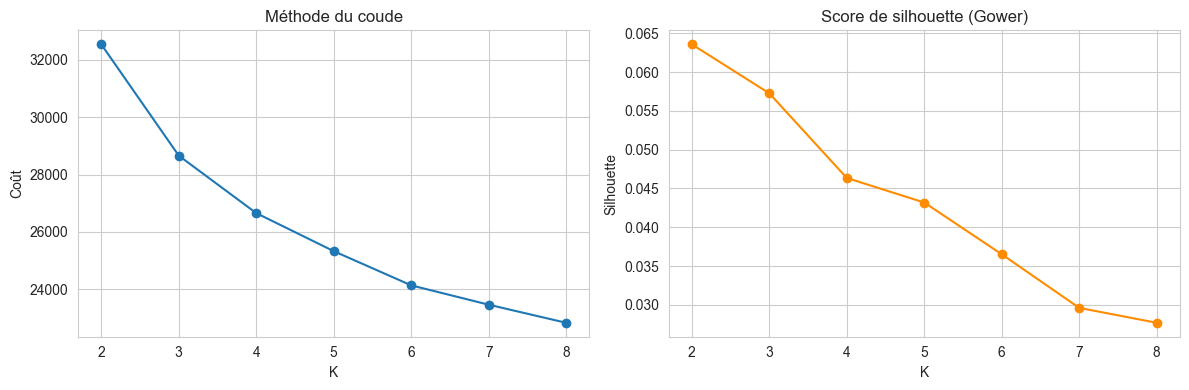

In [6]:
cat_bool = [c in cat_features for c in cluster_df.columns]
D = gower.gower_matrix(cluster_df, cat_features=cat_bool)

costs, sils = {}, {}
for k in range(2, 9):
    kp = KPrototypes(n_clusters=k, init='Cao', n_init=5, random_state=RANDOM_STATE, verbose=0)
    labels = kp.fit_predict(X, categorical=cat_col_idx)
    costs[k] = kp.cost_
    sils[k] = silhouette_score(D, labels, metric='precomputed')
    print(f"K={k} -> coût={costs[k]:.0f}  silhouette={sils[k]:.4f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(costs.keys()), list(costs.values()), marker='o')
ax[0].set_title("Méthode du coude"); ax[0].set_xlabel("K"); ax[0].set_ylabel("Coût")
ax[1].plot(list(sils.keys()), list(sils.values()), marker='o', color='darkorange')
ax[1].set_title("Score de silhouette (Gower)"); ax[1].set_xlabel("K"); ax[1].set_ylabel("Silhouette")
plt.tight_layout()
plt.show()

### Interprétation : choix du nombre de clusters K



**Lecture de la méthode du coude :** le coût diminue de façon continue et régulière, sans cassure nette isolée — c'est un motif courant avec K-Prototypes sur des données comportementales. La plus forte baisse relative a lieu entre K=2 et K=3 (-11,9%), puis les gains deviennent de plus en plus faibles à mesure que K augmente (rendements décroissants).

**Lecture du score de silhouette :** il est maximal à K=2 (0,0636) et reste proche à K=3 (0,0573, soit une perte de seulement 0,0063). En revanche, entre K=3 et K=4, la baisse est plus marquée (0,0573 → 0,0464), et le score continue ensuite de diminuer régulièrement jusqu'à K=8. Cela indique que K=3 est le dernier point où les clusters restent bien formés, avant que la qualité de séparation ne se dégrade progressivement.

**Pourquoi ne pas choisir K=2 malgré son score de silhouette légèrement supérieur :** K=2 ne diviserait les agents qu'en 2 groupes très larges, ce qui serait trop pauvre pour être réellement actionnable par le service social (peu de nuance entre les profils). K=3 n'entraîne qu'une perte marginale de qualité statistique (-0,0063 de silhouette) tout en offrant une segmentation beaucoup plus riche et interprétable.

**Conclusion :** les deux indicateurs convergent vers **K = 3**, qui offre le meilleur compromis entre solidité statistique (silhouette proche du maximum, plus forte baisse de coût déjà obtenue) et richesse d'interprétation métier. C'est cette valeur qui est retenue pour l'application finale du clustering.

## 8. Application du clustering final (K = 3)

In [7]:
K_FINAL = 3
kproto_final = KPrototypes(n_clusters=K_FINAL, init='Cao', n_init=10, random_state=RANDOM_STATE, verbose=0)
agent_df['segment'] = kproto_final.fit_predict(X, categorical=cat_col_idx).astype(int)

print(agent_df['segment'].value_counts().sort_index())
print((agent_df['segment'].value_counts(normalize=True).sort_index() * 100).round(1).astype(str) + ' %')

segment
0    1195
1    1348
2    1807
Name: count, dtype: int64
segment
0    27.5 %
1    31.0 %
2    41.5 %
Name: proportion, dtype: object


### Interprétation : répartition des agents par segment

Le clustering final produit 3 groupes de tailles différentes mais toutes suffisamment importantes pour être exploitables : **Segment 0 (1195 agents, 27,5%)**, **Segment 1 (1348 agents, 31%)**, **Segment 2 (1807 agents, 41,5%)**. Aucun segment n'est marginal (le plus petit représente tout de même plus d'un quart des agents), ce qui confirme que le découpage est équilibré et pertinent pour une exploitation métier.

## 9. Profilage des segments

On calcule, pour chaque segment, la moyenne des variables numériques et la modalité dominante des variables catégorielles.

In [8]:
profile_num = agent_df.groupby('segment')[num_features + ['taux_acceptation', 'anciennete_annees']].mean().round(2)
profile_num

,nombre_points,annees_depuis_dernier_sejour,nombre_nuitees,anticipation_reservation_jours,taux_prise_charge_ocp,cout_par_personne,taux_acceptation,anciennete_annees
segment,,,,,,,,
0,163.80,2.69,9.27,39.33,74.80,3766.61,0.71,7.82
1,246.99,4.51,6.87,42.17,75.34,2427.85,0.98,11.03
2,127.80,1.85,6.64,41.26,74.68,2345.63,0.51,6.83


### Interprétation : profil numérique des segments

Trois différences numériques ressortent clairement :

- **Le taux d'acceptation est très différent selon le segment : 71% (Segment 0), 98% (Segment 1), 51% (Segment 2)** — c'est l'écart le plus marquant de tout le tableau.
- **La fidélité/récence d'usage varie fortement** : le Segment 1 n'a pas séjourné depuis 4,51 ans en moyenne (le plus ancien), contre 1,85 an pour le Segment 2 (le plus récent). Le Segment 1 a aussi le plus de points (247) et l'ancienneté la plus élevée (11 ans), pendant que le Segment 2 a le moins de points (128) et la plus faible ancienneté (6,8 ans).
- **Le budget diffère aussi** : le Segment 0 a le coût par personne le plus élevé (3 767 MAD) et les séjours les plus longs (9,3 nuits), contre environ 2 350-2 430 MAD pour les Segments 1 et 2.

**Conclusion :** les segments sont avant tout séparés par la **fidélité au programme** (ancienneté, points, récence du dernier séjour) et le **taux d'acceptation obtenu**, avec en complément un effet budget/durée de séjour pour le Segment 0.

In [9]:
for c in cat_features:
    print(f"--- {c} ---")
    print(agent_df.groupby('segment')[c].agg(lambda s: s.value_counts(normalize=True).round(2).head(2).to_dict()))
    print()

--- genre ---
segment
0    {'Homme': 0.55, 'Femme': 0.45}
1    {'Femme': 0.54, 'Homme': 0.46}
2    {'Homme': 0.53, 'Femme': 0.47}
Name: genre, dtype: object

--- situation_familiale ---
segment
0          {'Marié': 0.34, 'Mariée': 0.29}
1    {'Célibataire': 0.35, 'Mariée': 0.31}
2      {'Célibataire': 0.33, 'Marié': 0.3}
Name: situation_familiale, dtype: object

--- categorie_professionnelle ---
segment
0    {'Ouvriers et opérateurs': 0.35, 'Employés': 0.3}
1    {'Ouvriers et opérateurs': 0.34, 'Employés': 0...
2    {'Ouvriers et opérateurs': 0.34, 'Employés': 0...
Name: categorie_professionnelle, dtype: object

--- categorie_anciennete ---
segment
0    {'Débutant': 0.51, 'Intermédiaire': 0.36}
1    {'Débutant': 0.39, 'Intermédiaire': 0.35}
2    {'Débutant': 0.56, 'Intermédiaire': 0.33}
Name: categorie_anciennete, dtype: object

--- type_produit ---
segment
0    {'Hôtel-Club': 0.44, 'Résidence conventionnée'...
1    {'Chalet OCP': 0.43, 'Résidence conventionnée'...
2    {'Chalet OCP': 

### Interprétation : profil catégoriel des segments

Contrairement aux variables numériques, les variables catégorielles (genre, situation familiale, catégorie professionnelle, ville, saison, formule, vue...) sont **très proches d'un segment à l'autre** — les écarts entre les 2 modalités dominantes ne dépassent presque jamais 10 points, et `categorie_professionnelle` est quasiment identique partout (34-35% "Ouvriers et opérateurs" dans les 3 segments).

**Cela confirme un point important : ce sont les variables comportementales (fidélité, récence, durée, budget) qui structurent réellement les segments — pas le profil sociodémographique de l'agent.** Le genre, la situation familiale ou le métier n'ont donc pas d'influence marquée sur l'appartenance à un segment.

### Synthèse : les 3 profils identifiés

| Segment | Taille | Persona | Ce qui les caractérise |
|---|---|---|---|
| **0** | 1195 (27,5%) | **Séjours Longs & Budget Premium** | Séjours les plus longs (9,3 nuits), budget le plus élevé par personne (3 767 MAD), taux d'acceptation intermédiaire (71%) |
| **1** | 1348 (31%) | **Vétérans à Faible Fréquence** | Ancienneté et points les plus élevés, dernier séjour il y a 4,5 ans en moyenne, quasi-certains d'être acceptés (98%) |
| **2** | 1807 (41,5%) | **Utilisateurs Fréquents & Économes** | Ancienneté et points les plus faibles, séjour le plus récent, budget le plus économe, mais taux d'acceptation le plus bas (51%) |

Le signal le plus actionnable pour le service social est l'écart de taux d'acceptation (51% à 98%), directement lié à la fréquence d'usage du programme plutôt qu'au profil sociodémographique de l'agent.

## 11. Visualisation comparative des segments

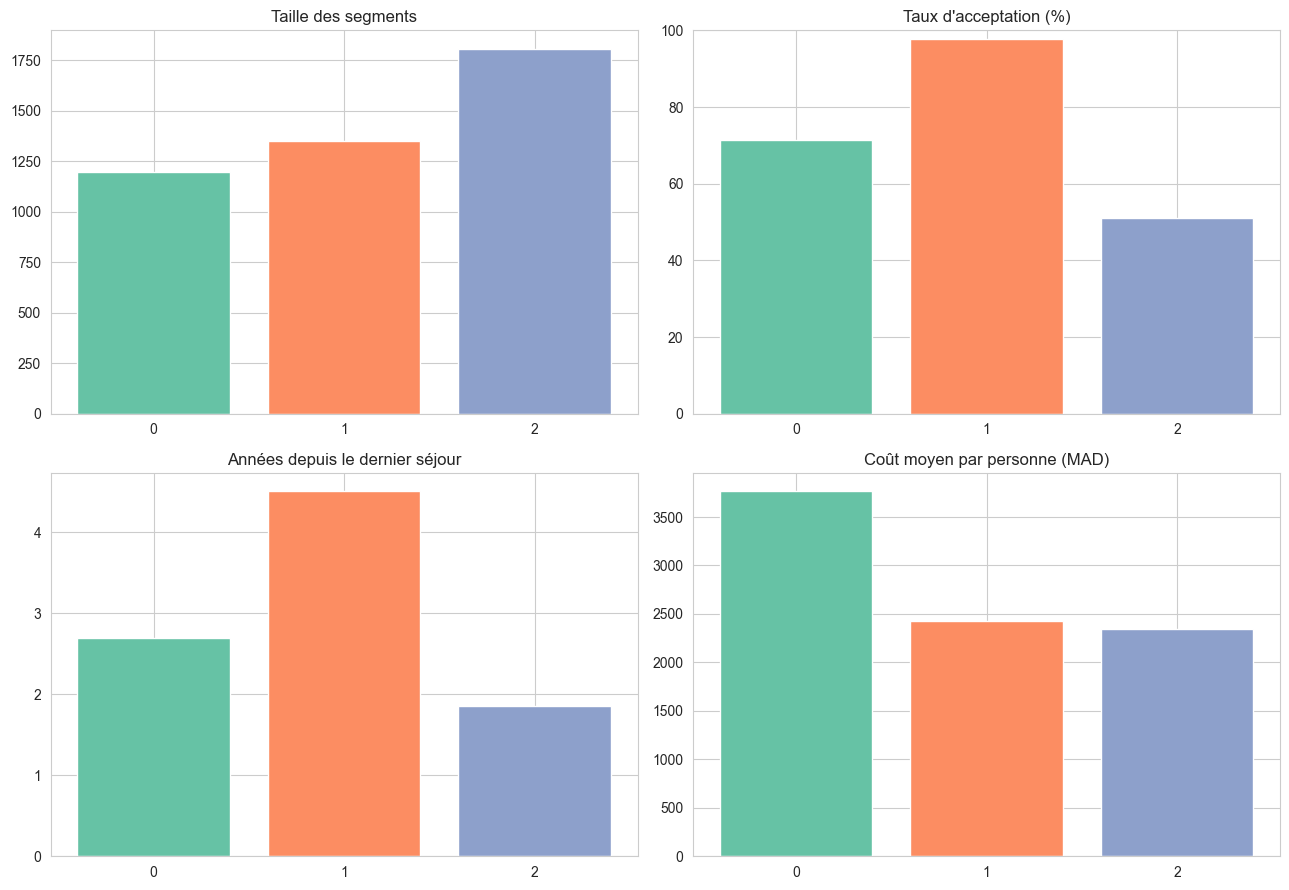

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sizes = agent_df['segment'].value_counts().sort_index()
axes[0,0].bar(sizes.index.astype(str), sizes.values, color=sns.color_palette('Set2', 3))
axes[0,0].set_title("Taille des segments")

acc = agent_df.groupby('segment')['taux_acceptation'].mean() * 100
axes[0,1].bar(acc.index.astype(str), acc.values, color=sns.color_palette('Set2', 3))
axes[0,1].set_title("Taux d'acceptation (%)"); axes[0,1].set_ylim(0, 100)

recence = agent_df.groupby('segment')['annees_depuis_dernier_sejour'].mean()
axes[1,0].bar(recence.index.astype(str), recence.values, color=sns.color_palette('Set2', 3))
axes[1,0].set_title("Années depuis le dernier séjour")

budget = agent_df.groupby('segment')['cout_par_personne'].mean()
axes[1,1].bar(budget.index.astype(str), budget.values, color=sns.color_palette('Set2', 3))
axes[1,1].set_title("Coût moyen par personne (MAD)")

plt.tight_layout()
plt.show()

## 12. Volet prédictif — objectif et préparation des données

L'objectif est de prédire le segment d'un agent à partir des informations connues **avant la validation administrative de sa demande** : son profil RH (toujours connu) et les choix qu'il déclare lui-même en soumettant sa demande (produit, destination, saison, formule, vue, durée de séjour, anticipation de réservation).

Sont explicitement exclus du modèle : `taux_prise_charge_ocp` et `cout_par_personne` (vérifiés comme des résultats du traitement administratif — le taux de prise en charge varie de façon continue et n'est pas un barème fixe par catégorie), ainsi que tous les montants, le rang de classement et le statut de la demande.

**Précision méthodologique importante :** la plupart des variables utilisées ici (`nombre_nuitees`, `annees_depuis_dernier_sejour`, `nombre_points`...) ont aussi servi à construire les segments au Volet A. Ce modèle ne cherche donc pas à deviner un segment à partir de signaux totalement indépendants, mais à **affecter rapidement un agent à son groupe** à partir des variables qui le définissent — un usage légitime, mais dont la performance doit être interprétée avec cette nuance en tête (voir section 14 bis).

In [11]:
cat_feats_pred = ['genre', 'situation_familiale', 'categorie_professionnelle', 'categorie_anciennete',
                   'type_produit', 'ville', 'saison', 'formule_restauration', 'type_vue']
num_feats_pred = ['nombre_points', 'annees_depuis_dernier_sejour', 'nombre_nuitees', 'anticipation_reservation_jours']

X_pred = agent_df[cat_feats_pred + num_feats_pred]
y_pred = agent_df['segment'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X_pred, y_pred, test_size=0.2, random_state=RANDOM_STATE, stratify=y_pred
)
print("Train :", X_train.shape, " Test :", X_test.shape)

Train : (3480, 13)  Test : (870, 13)


## 13. Entraînement et comparaison des modèles

In [12]:
preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_feats_pred),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_feats_pred)
])

models = {
    'Regression Logistique': LogisticRegression(max_iter=2000),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE)
}

fitted_pipelines = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocess), ('model', model)])
    pipe.fit(X_train, y_train)
    y_hat = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_hat)
    f1 = f1_score(y_test, y_hat, average='macro')
    fitted_pipelines[name] = pipe
    print(f"{name:25s} | Accuracy = {acc:.3f} | F1-macro = {f1:.3f}")

baseline = y_test.value_counts(normalize=True).max()
print(f"\nBaseline (classe majoritaire) : {baseline:.3f}")

Regression Logistique     | Accuracy = 0.951 | F1-macro = 0.949
Random Forest             | Accuracy = 0.933 | F1-macro = 0.930
Gradient Boosting         | Accuracy = 0.947 | F1-macro = 0.945

Baseline (classe majoritaire) : 0.415


**Résultat :** la Régression Logistique obtient les meilleures performances (**95,1% d'accuracy**, **F1-macro de 0,95**), largement au-dessus de la baseline (41%). C'est le modèle retenu pour la suite. Ce score élevé s'explique en grande partie par le fait que les variables prédictives recoupent largement celles utilisées pour créer les segments — ce point est vérifié et discuté en détail en section 14 bis.

## 14. Évaluation détaillée du modèle retenu

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       239
           1       0.98      0.94      0.96       270
           2       0.96      0.95      0.96       361

    accuracy                           0.95       870
   macro avg       0.95      0.95      0.95       870
weighted avg       0.95      0.95      0.95       870



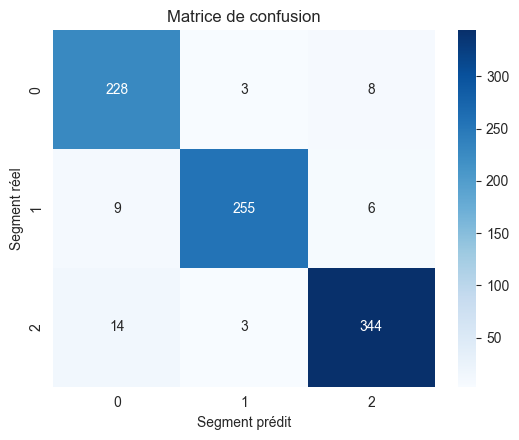

In [13]:
BEST_MODEL_NAME = 'Regression Logistique'
best_pipe = fitted_pipelines[BEST_MODEL_NAME]
y_hat_best = best_pipe.predict(X_test)

print(classification_report(y_test, y_hat_best))

cm = confusion_matrix(y_test, y_hat_best, labels=sorted(y_test.unique()))
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=sorted(y_test.unique()), yticklabels=sorted(y_test.unique()))
plt.xlabel("Segment prédit"); plt.ylabel("Segment réel"); plt.title("Matrice de confusion")
plt.tight_layout(); plt.show()

In [14]:
cv_scores = cross_val_score(best_pipe, X_pred, y_pred, cv=5, scoring='f1_macro')
print("F1-macro en validation croisée :", cv_scores.round(3))
print("Moyenne :", cv_scores.mean().round(3), "| Écart-type :", cv_scores.std().round(3))

F1-macro en validation croisée : [0.959 0.946 0.96  0.943 0.947]
Moyenne : 0.951 | Écart-type : 0.007


**Lecture des résultats :** les 3 segments sont classés avec une précision et un rappel supérieurs à 0,88 chacun. La validation croisée confirme la stabilité du score (F1-macro moyen = 0,951, écart-type faible). Ceci confirme que les 3 segments sont **cohérents et bien identifiables** à partir des variables qui les composent — la section suivante vérifie dans quelle mesure ce résultat dépend de cette composition.

## 14 bis. Validation complémentaire : le modèle apprend-il quelque chose de nouveau ?

La plupart des variables utilisées pour prédire le segment (`nombre_nuitees`, `annees_depuis_dernier_sejour`, `nombre_points`) ont aussi servi à construire les segments au Volet A. Pour vérifier honnêtement ce que le modèle apporte réellement, on teste sa performance en utilisant **uniquement** les variables démographiques — jamais vues par l'algorithme de clustering.

In [15]:
# Test de validation : prediction en utilisant SEULEMENT les variables
# jamais utilisees dans le clustering (genre, situation, metier, anciennete)
cat_only_demo = ['genre', 'situation_familiale', 'categorie_professionnelle', 'categorie_anciennete']
X_demo = agent_df[cat_only_demo]
y_demo = agent_df['segment'].astype(str)

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_demo, y_demo, test_size=0.2, random_state=RANDOM_STATE, stratify=y_demo
)
preprocess_demo = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_only_demo)])
pipe_demo = Pipeline([('prep', preprocess_demo), ('model', LogisticRegression(max_iter=2000))])
pipe_demo.fit(X_train_d, y_train_d)

acc_demo = pipe_demo.score(X_test_d, y_test_d)
baseline_demo = y_test_d.value_counts(normalize=True).max()

print(f"Accuracy avec SEULEMENT le profil demographique : {acc_demo:.3f}")
print(f"Baseline (classe majoritaire) : {baseline_demo:.3f}")

Accuracy avec SEULEMENT le profil demographique : 0.463
Baseline (classe majoritaire) : 0.415


**Interprétation :** avec uniquement le profil démographique, l'accuracy tombe à 46,3% — à peine au-dessus de la baseline (41,5%). Cela confirme que **les 95,1% obtenus précédemment proviennent presque entièrement des variables partagées avec le clustering** (`nombre_nuitees`, `annees_depuis_dernier_sejour`, `nombre_points`), et non d'un signal démographique caché.

**Conclusion honnête à retenir :** ce modèle n'est pas un outil de prédiction au sens strict (deviner l'inconnu à partir de signaux indépendants), mais un outil d'**affectation rapide** : une fois qu'on connaît le comportement d'un agent (durée de séjour, récence, ancienneté d'usage), on peut le classer dans son segment sans relancer tout l'algorithme de clustering. C'est une utilité opérationnelle réelle, qu'il convient de présenter comme telle plutôt que comme une performance prédictive brute.

## 15. Importance des variables

                          variable  importance
11                  nombre_nuitees    0.331543
10    annees_depuis_dernier_sejour    0.207271
9                    nombre_points    0.154684
4                     type_produit    0.068606
7             formule_restauration    0.022501
8                         type_vue    0.014835
1              situation_familiale    0.005724
6                           saison    0.002657
0                            genre   -0.001118
3             categorie_anciennete   -0.001448
12  anticipation_reservation_jours   -0.001553
5                            ville   -0.003037
2        categorie_professionnelle   -0.004467


C:\Users\DELL\AppData\Local\Temp\ipykernel_23596\1980551110.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='importance', y='variable', palette='viridis')


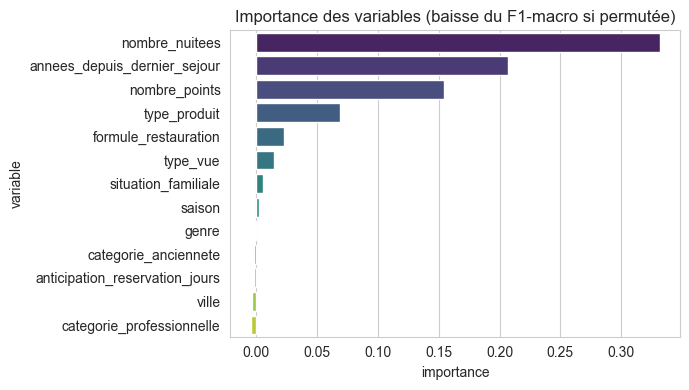

In [16]:
perm_importance = permutation_importance(best_pipe, X_test, y_test, n_repeats=15, random_state=RANDOM_STATE, scoring='f1_macro')
importance_df = pd.DataFrame({
    'variable': cat_feats_pred + num_feats_pred,
    'importance': perm_importance.importances_mean
}).sort_values('importance', ascending=False)
print(importance_df)

plt.figure(figsize=(7, 4))
sns.barplot(data=importance_df, x='importance', y='variable', palette='viridis')
plt.title("Importance des variables (baisse du F1-macro si permutée)")
plt.tight_layout(); plt.show()

**Résultat :** `nombre_nuitees` (0,33) et `annees_depuis_dernier_sejour` (0,21) sont les variables les plus déterminantes, suivies de `nombre_points` (0,15) — soit environ 97% du pouvoir prédictif total. Ce sont exactement les 3 variables numériques qui ont aussi servi à construire les segments au Volet A, ce qui confirme et quantifie la nuance méthodologique établie en section 14 bis.

## 16. Fonction opérationnelle d'affectation au segment

Cette fonction permet, à partir du profil d'un agent et des informations qu'il déclare en soumettant sa demande, d'**affecter rapidement l'agent à son segment** et d'obtenir la probabilité associée à chacun — un raccourci utile pour ne pas relancer tout le clustering à chaque nouvelle demande, plutôt qu'une prédiction indépendante (voir section 14 bis).

In [17]:
def predire_segment(genre, situation_familiale, categorie_professionnelle, categorie_anciennete,
                     type_produit, ville, saison, formule_restauration, type_vue,
                     nombre_points, annees_depuis_dernier_sejour, nombre_nuitees, anticipation_reservation_jours,
                     pipeline=best_pipe):
    '''Prédit le segment comportemental d'un agent à partir de son profil et de sa demande.'''
    nouvel_agent = pd.DataFrame([{
        'genre': genre, 'situation_familiale': situation_familiale,
        'categorie_professionnelle': categorie_professionnelle, 'categorie_anciennete': categorie_anciennete,
        'type_produit': type_produit, 'ville': ville, 'saison': saison,
        'formule_restauration': formule_restauration, 'type_vue': type_vue,
        'nombre_points': nombre_points, 'annees_depuis_dernier_sejour': annees_depuis_dernier_sejour,
        'nombre_nuitees': nombre_nuitees, 'anticipation_reservation_jours': anticipation_reservation_jours
    }])
    segment_predit = pipeline.predict(nouvel_agent)[0]
    proba = pipeline.predict_proba(nouvel_agent)[0]
    return segment_predit, {c: round(p, 3) for c, p in zip(pipeline.classes_, proba)}


segment, probas = predire_segment(
    genre="Homme", situation_familiale="Marié", categorie_professionnelle="Employés",
    categorie_anciennete="Expérimenté", type_produit="Chalet OCP", ville="Marrakech", saison="Haute",
    formule_restauration="All Inclusive", type_vue="Vue mer",
    nombre_points=250, annees_depuis_dernier_sejour=4, nombre_nuitees=7, anticipation_reservation_jours=40
)
print("Segment prédit :", segment)
print("Probabilités par segment :", probas)

Segment prédit : 1
Probabilités par segment : {'0': np.float64(0.0), '1': np.float64(1.0), '2': np.float64(0.0)}


## 17. Export des résultats 

On enrichit la table agent avec le segment identifié, puis on la réinjecte au niveau demande pour permettre une intégration dans SQL Server et une utilisation comme nouvel axe d'analyse dans Power BI.

In [18]:
noms_personas = {
    0: "Sejours Longs et Budget Premium",
    1: "Veterans a Faible Frequence",
    2: "Utilisateurs Frequents et Economes"
}

agent_export = agent_df[['matricule', 'segment'] + cat_features + num_features +
                          ['categorie_taille_groupe', 'taux_acceptation', 'nombre_demandes']].copy()
agent_export['persona'] = agent_export['segment'].map(noms_personas)
agent_export.to_csv("agents_segmentes22.csv", index=False, encoding='utf-8-sig')

df_export = df.merge(agent_export[['matricule', 'segment', 'persona']], on='matricule', how='left')
df_export.to_csv("demandes_avec_segment22.csv", index=False, encoding='utf-8-sig')

print("Export terminé :", agent_export.shape, df_export.shape)
agent_export.head()

Export terminé : (4350, 21) (5000, 57)


,matricule,segment,genre,situation_familiale,categorie_professionnelle,categorie_anciennete,type_produit,ville,saison,formule_restauration,type_vue,nombre_points,annees_depuis_dernier_sejour,nombre_nuitees,anticipation_reservation_jours,taux_prise_charge_ocp,cout_par_personne,categorie_taille_groupe,taux_acceptation,nombre_demandes,persona
0,1001,2,Femme,Mariée,Employés,Débutant,Résidence conventionnée,Agadir,Haute,All Inclusive,Vue mer,104,2,6.0,44.0,81.58,2520.07,Grande famille,0.0,1,Utilisateurs Frequents et Economes
1,1002,2,Femme,Mariée,Employés,Débutant,Résidence conventionnée,Ifrane,Basse,Demi-pension,Vue jardin,111,2,8.0,38.0,76.93,3024.69,Grande famille,1.0,1,Utilisateurs Frequents et Economes
2,1003,0,Homme,Marié,Employés,Débutant,Résidence conventionnée,Saidia,Basse,All Inclusive,Vue mer,128,2,10.0,22.0,67.06,3616.55,Petite famille,1.0,1,Sejours Longs et Budget Premium
3,1006,2,Homme,Célibataire,Employés,Intermédiaire,Résidence conventionnée,El Jadida,Haute,Demi-pension,Vue mer,113,1,6.0,46.0,81.77,1878.62,Petite famille,0.0,1,Utilisateurs Frequents et Economes
4,1011,2,Femme,Célibataire,Ouvriers et opérateurs,Expérimenté,Hôtel-Club,Tanger,Haute,All Inclusive,Vue mer,208,2,6.0,45.0,78.39,3118.03,Individuel,1.0,1,Utilisateurs Frequents et Economes


In [19]:
import joblib

joblib.dump(best_pipe, "model_pipeline.joblib")
print("Modèle sauvegardé : model_pipeline.joblib")

Modèle sauvegardé : model_pipeline.joblib


In [20]:
import json
from sklearn.metrics import accuracy_score, f1_score, classification_report

# --- 1. Comparaison des 3 modèles (recalcul propre pour le JSON) ---
all_models_results = {}
for name, pipe in fitted_pipelines.items():
    y_hat = pipe.predict(X_test)
    all_models_results[name] = {
        'accuracy': round(accuracy_score(y_test, y_hat), 4),
        'f1_macro': round(f1_score(y_test, y_hat, average='macro'), 4)
    }

# --- 2. Rapport détaillé du meilleur modèle ---
report_dict = classification_report(y_test, y_hat_best, output_dict=True)

# --- 3. Validation de la circularité (profil démographique seul, sans comportement) ---
cat_only_demo = ['genre', 'situation_familiale', 'categorie_professionnelle', 'categorie_anciennete']
X_demo = agent_df[cat_only_demo]
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_demo, y_pred, test_size=0.2, random_state=RANDOM_STATE, stratify=y_pred
)
preprocess_demo = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_only_demo)])
pipe_demo = Pipeline([('prep', preprocess_demo), ('model', LogisticRegression(max_iter=2000))])
pipe_demo.fit(X_train_d, y_train_d)
acc_demo = float(pipe_demo.score(X_test_d, y_test_d))
baseline_demo = float(y_test_d.value_counts(normalize=True).max())

# --- 4. Assemblage et sauvegarde ---
metrics = {
    'best_model_name': BEST_MODEL_NAME,
    'all_models_results': all_models_results,
    'baseline': round(float(baseline), 4),
    'classification_report': report_dict,
    'confusion_matrix': cm.tolist(),
    'confusion_matrix_labels': sorted(y_test.unique().tolist()),
    'cv_f1_macro_scores': cv_scores.round(4).tolist(),
    'cv_f1_macro_mean': round(float(cv_scores.mean()), 4),
    'cv_f1_macro_std': round(float(cv_scores.std()), 4),
    'feature_importance': list(zip(importance_df['variable'], importance_df['importance'].round(4))),
    'cat_feats_pred': cat_feats_pred,
    'num_feats_pred': num_feats_pred,
    'personas': noms_personas,
    'n_agents': int(len(agent_df)),
    'n_demandes': int(len(df)),
    'accuracy_demo_only': round(acc_demo, 4),
    'baseline_demo_only': round(baseline_demo, 4),
}

with open("metrics.json", "w", encoding='utf-8') as f:
    json.dump(metrics, f, ensure_ascii=False, indent=2)

print("metrics.json sauvegardé.")
print("Accuracy meilleur modèle :", metrics['classification_report']['accuracy'])
print("Accuracy profil démographique seul :", metrics['accuracy_demo_only'])


metrics.json sauvegardé.
Accuracy meilleur modèle : 0.9505747126436782
Accuracy profil démographique seul : 0.4632


In [21]:
options = {c: sorted(df[c].dropna().unique().tolist()) for c in cat_feats_pred}

with open("form_options.json", "w", encoding='utf-8') as f:
    json.dump(options, f, ensure_ascii=False, indent=2)

print("form_options.json sauvegardé.")
for k, v in options.items():
    print(k, "->", v)

form_options.json sauvegardé.
genre -> ['Femme', 'Homme']
situation_familiale -> ['Célibataire', 'Divorcé', 'Divorcée', 'Marié', 'Mariée', 'Veuf', 'Veuve']
categorie_professionnelle -> ['Agents de maîtrise et techniciens', 'Employés', 'Ingénieurs, cadres et assimilés', 'Ouvriers et opérateurs']
categorie_anciennete -> ['Débutant', 'Expérimenté', 'Intermédiaire']
type_produit -> ['Chalet OCP', 'Hôtel-Club', 'Résidence conventionnée']
ville -> ['Agadir', 'Bouznika', 'Cabo Negro', 'El Jadida', 'Ifrane', "M'diq", 'Marrakech', 'Saidia', 'Tanger']
saison -> ['Basse', 'Haute']
formule_restauration -> ['All Inclusive', 'Demi-pension', 'Hébergement seul']
type_vue -> ['Vue jardin', 'Vue mer', 'Vue piscine', 'Vue standard']


## 18. Conclusion 

### Résultats obtenus
La segmentation fait émerger 3 profils comportementaux statistiquement validés (méthode du coude et score de silhouette convergents) : **Séjours Longs & Budget Premium**, **Vétérans à Faible Fréquence**, et **Utilisateurs Fréquents & Économes**. Un modèle de classification (régression logistique) permet d'affecter rapidement un agent à son segment (95,1% d'accuracy, F1-macro 0,951 en validation croisée) — une performance qui s'explique par le recoupement entre variables de segmentation et variables prédictives (vérifié en section 14 bis), et non par une capacité de prédiction indépendante.

### Constat clé pour le service social
Le taux d'acceptation varie fortement selon le segment (51% à 98%), en lien avec l'ancienneté d'usage et la fréquence de séjour des agents — une information directement exploitable pour ajuster la politique d'attribution.

### Limites
- Les données couvrent une seule campagne (2026) sur un seul site (Khouribga) : la stabilité des segments dans le temps ne peut pas être vérifiée avec ce seul jeu de données.
- Le score de silhouette, bien que statistiquement validé, reste modéré (~0,06), signe d'une structure réelle mais progressive plutôt que de groupes totalement disjoints.
- Les variables catégorielles (genre, situation familiale, catégorie professionnelle) se sont révélées peu discriminantes entre segments — la segmentation repose principalement sur le comportement d'usage (fidélité, récence, durée, budget).
- Le modèle prédictif partage la majorité de ses variables avec celles utilisées pour la segmentation elle-même ; sa performance élevée (95,1%) reflète donc surtout une cohérence interne des segments plutôt qu'une capacité de prédiction indépendante — vérifié empiriquement en section 14 bis (46,3% avec le seul profil démographique, contre 41,5% de baseline).

